In [24]:
import pandas as pd
import numpy as np

# Load the CLEAN data we saved in Phase 3
df = pd.read_csv('../data/processed/survey_clean.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (42723, 7)


,Country,EdLevel,YearsCodePro,Employment,DevType,OrgSize,ConvertedCompYearly
0,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",23.0,"Employed, full-time","Developer, back-end","5,000 to 9,999 employees",250000.0
1,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",7.0,"Employed, full-time","Developer, front-end",100 to 499 employees,156000.0
2,Philippines,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4.0,"Employed, full-time;Independent contractor, fr...","Developer, full-stack",20 to 99 employees,23456.0
3,United Kingdom of Great Britain and Northern I...,Some college/university study without earning ...,21.0,"Employed, full-time","Developer, back-end",100 to 499 employees,96828.0
4,United States of America,Some college/university study without earning ...,3.0,"Employed, full-time","Developer, full-stack","1,000 to 4,999 employees",135000.0


In [25]:
text_columns = ['Country', 'EdLevel', 'Employment', 'DevType', 'OrgSize']

for col in text_columns:
    unique_count = df[col].nunique()
    print(f"\n{col} - {unique_count} unique values:")
    print(df[col].value_counts().head(5))
    print("...")


Country - 160 unique values:
Country
United States of America                                10567
Germany                                                  3876
United Kingdom of Great Britain and Northern Ireland     3463
Canada                                                   2033
France                                                   1779
Name: count, dtype: int64
...

EdLevel - 8 unique values:
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          19738
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       11968
Some college/university study without earning a degree                                 4987
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2049
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     1918
Name: count, dtype: int64
...

Employment - 14 unique values:
Employment
Employed, full-time                                  

In [26]:
def clean_country(country, threshold=400):
    """
    Keep countries with more than `threshold` respondents.
    Group everything else as 'Other'.
    """
    # Count how many times each country appears
    country_count = df['Country'].value_counts()

    # If this country has fewer than threshold responses, call it 'Other'
    if country_count[country] < threshold:
        return 'Other'
    return country

df['Country'] = df['Country'].apply(clean_country)

print(f"Unique contries after cleaning: {df['Country'].unique()}")
print(df['Country'].value_counts())

Unique contries after cleaning: ['United States of America' 'Other'
 'United Kingdom of Great Britain and Northern Ireland' 'Finland'
 'Australia' 'Netherlands' 'Germany' 'Sweden' 'France' 'Spain' 'Brazil'
 'Portugal' 'Italy' 'Canada' 'Switzerland' 'India' 'Austria' 'Norway'
 'Poland' 'Belgium' 'Denmark' 'Czech Republic' 'New Zealand']
Country
United States of America                                10567
Other                                                    7470
Germany                                                  3876
United Kingdom of Great Britain and Northern Ireland     3463
Canada                                                   2033
France                                                   1779
Netherlands                                              1326
India                                                    1305
Poland                                                   1185
Australia                                                1178
Spain                             

In [30]:
def clean_education(edu):
    """
    Simplify the verbose education labels into 
    clean, meaningful categories.
    """
    if 'Bachelor' in str(edu):
        return 'Bachelor'
    elif 'Master' in str(edu):
        return 'Master'
    elif 'doctoral' in str(edu) or 'Ph.D' in str(edu):
        return 'PhD'
    elif 'Associate' in str(edu):
        return 'Associate'
    elif 'without earning' in str(edu) or 'without degree' in str(edu):
        return 'No Degree'
    elif 'never completed' in str(edu) or 'Primary' in str(edu):
        return 'No Degree'
    else:
        return 'Other'
    
df['EdLevel'] = df['EdLevel'].apply(clean_education)

print("\nAfter cleaning:")
print(df['EdLevel'].value_counts())



After cleaning:
EdLevel
Bachelor     19738
Master       11968
Other         9561
Associate     1456
Name: count, dtype: int64


In [31]:
from sklearn.preprocessing import LabelEncoder

# These are all the columns that need encoding
categorical_columns = ['Country', 'EdLevel', 'Employment', 'DevType', 'OrgSize']

# We'll store the encoders so we can reverse the transformation later
# (important for the web app — we need to convert back to show users!)
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded '{col}' - {len(le.classes_)} unique values")

print("\nDataset after encoding:")
df.head()

Encoded 'Country' - 23 unique values
Encoded 'EdLevel' - 4 unique values
Encoded 'Employment' - 14 unique values
Encoded 'DevType' - 34 unique values
Encoded 'OrgSize' - 11 unique values

Dataset after encoding:


,Country,EdLevel,YearsCodePro,Employment,DevType,OrgSize,ConvertedCompYearly
0,22,1,23.0,0,11,6,250000.0
1,22,1,7.0,0,14,3,156000.0
2,15,1,4.0,2,15,5,23456.0
3,21,3,21.0,0,11,3,96828.0
4,22,3,3.0,0,15,0,135000.0


In [33]:
print("Data types after encoding:")
print(df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nAny text columns remaining?")
print(df.select_dtypes(include=['object']).columns.tolist())

Data types after encoding:
(42723, 7)

First 3 rows:
   Country  EdLevel  YearsCodePro  Employment  DevType  OrgSize  \
0       22        1          23.0           0       11        6   
1       22        1           7.0           0       14        3   
2       15        1           4.0           2       15        5   

   ConvertedCompYearly  
0             250000.0  
1             156000.0  
2              23456.0  

Any text columns remaining?
[]


In [35]:
import pickle

# Save the encoders to disk
with open('../data/processed/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("Label encoders saved!")

# Verify we can reload them correctly
with open('../data/processed/label_encoders.pkl', 'rb') as f:
    loaded_encoders = pickle.load(f)

# Test: decode the first value of 'Country' back to text
first_encoded_country = df['Country'].iloc[0]
decoded = loaded_encoders['Country'].inverse_transform([first_encoded_country])
print(f"\nTest decode: {first_encoded_country} → '{decoded[0]}'")

Label encoders saved!

Test decode: 22 → 'United States of America'


In [36]:
df.to_csv('../data/processed/survey_engineered.csv', index=False)
print("Engineered dataset saved!")
print(f"Final shape: {df.shape}")
print(f"\nFinal columns: {df.columns.tolist()}")
print(f"\nAll numeric? {df.select_dtypes(include=['object']).empty}")

Engineered dataset saved!
Final shape: (42723, 7)

Final columns: ['Country', 'EdLevel', 'YearsCodePro', 'Employment', 'DevType', 'OrgSize', 'ConvertedCompYearly']

All numeric? True


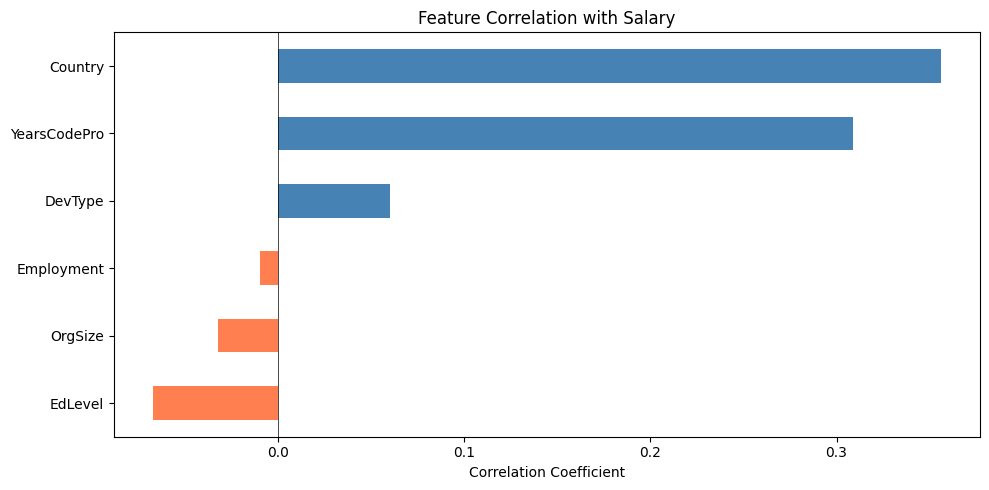


Most positively correlated with salary:
DevType         0.060386
YearsCodePro    0.308599
Country         0.355924
Name: ConvertedCompYearly, dtype: float64

Most negatively correlated with salary:
EdLevel      -0.067007
OrgSize      -0.032286
Employment   -0.009873
Name: ConvertedCompYearly, dtype: float64


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation of every feature with salary
correlations = df.corr()['ConvertedCompYearly'].drop('ConvertedCompYearly').sort_values()

plt.figure(figsize=(10, 5))
correlations.plot(kind='barh', color=['coral' if x < 0 else 'steelblue' for x in correlations])
plt.title('Feature Correlation with Salary')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nMost positively correlated with salary:")
print(correlations.tail(3))
print("\nMost negatively correlated with salary:")
print(correlations.head(3))